3
Variable       Type        Data/Info
------------------------------------
N              int         10
a              list        n=4
b              list        n=4
coeff          ndarray     3x3: 9 elems, type `float64`, 72 bytes
dx             ndarray     10: 10 elems, type `float64`, 80 bytes
i              int         1
k              int         5
n              int         3
np             module      <module 'numpy' from '/li<...>kages/numpy/__init__.py'>
plt            module      <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
spline_coeff   function    <function spline_coeff at 0x67e45a8>
x              ndarray     3: 3 elems, type `int32`, 12 bytes
x1             ndarray     20: 20 elems, type `float64`, 160 bytes
xs             ndarray     10: 10 elems, type `float64`, 80 bytes
xs1            ndarray     10: 10 elems, type `float64`, 80 bytes
xs2            ndarray     10: 10 elems, type `float64`, 80 bytes
y              ndarray     3: 3 elems, type `int32`, 12 

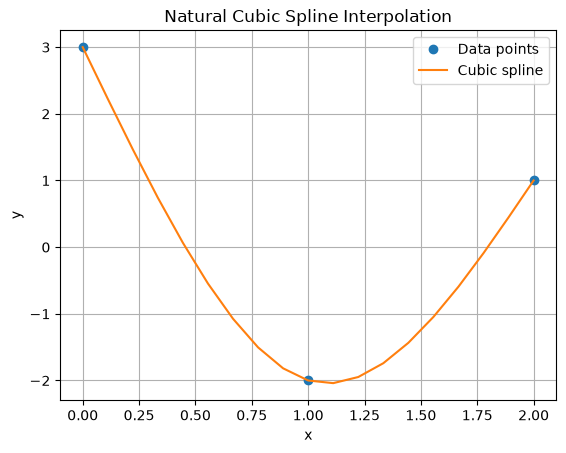

In [52]:
import numpy as np
import matplotlib.pyplot as plt


def spline_coeff(x, y):
    n = len(x)
    dx = np.diff(x)
    dy = np.diff(y)

    # Construct matrix A and right-hand-side vector r
    A = np.zeros((n, n))
    r = np.zeros(n)
	
    for i in range(1,n-1):
        A[i, i - 1:i + 2] = [dx[i - 1], 2 * (dx[i - 1] + dx[i]), dx[i]]

        r[i] = 3 * (dy[i] / dx[i] - dy[i - 1] / dx[i - 1])
    # Natural spline endpoint conditions
    A[0, 0] = 1
    A[-1, -1] = 1

    # Solve for c coefficients
    Ainv=np.linalg.inv(A)
    c=Ainv.dot(r)

    # Store coefficients as [b, c, d]
    coeff = np.zeros((n, 3))

    for i in range(n - 1):
        coeff[i, 2] = (c[i + 1] - c[i]) / (3 * dx[i])

        coeff[i, 0] = (dy[i] / dx[i]- dx[i] * (2 * c[i] + c[i + 1]) / 3)

        coeff[i, 1] = c[i]

    return coeff


# Input data points
x = np.array([0, 1, 2])
y = np.array([3, -2, 1])

# Number of interpolating points per spline interval
N = 10

n = len(x)
print(n)
coeff = spline_coeff(x, y)


# Evaluate each spline interval

xs1 = np.linspace(x[0], x[1], N)
xs2=np.linspace(x[1], x[2], N)

# spline equations
ys1=y[0]+coeff[0,0]*(xs1-x[0])+coeff[0,1]*(xs1-x[0])**2+coeff[0,2]*(xs1-x[0])**3
ys2=y[1]+coeff[1,0]*(xs2-x[1])+coeff[1,1]*(xs2-x[1])**2+coeff[1,2]*(xs2-x[1])**3

x1=np.concatenate((xs1, xs2))
y1=np.concatenate((ys1, ys2))

'''
Generalization of the spline equation 
for i in range(n - 1):
    xs = np.linspace(x[i], x[i + 1], N)
    dx = xs - x[i]

    # Nested multiplication
    ys = coeff[i, 2] * dx
    ys = (ys + coeff[i, 1]) * dx
    ys = (ys + coeff[i, 0]) * dx + y[i]

    x1.extend(xs)
    y1.extend(ys)

# Add the final endpoint
x1.append(x[-1])
y1.append(y[-1])
'''

# Plot the original points and spline
plt.plot(x, y, "o", label="Data points")
plt.plot(x1, y1, "-", label="Cubic spline")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Natural Cubic Spline Interpolation")
plt.grid(True)
plt.legend()
%whos
#plt.show()